In [1]:
from load_data import find_outliers, melt_demand, load_demand_raw, load_demand

find_outliers(melt_demand(load_demand_raw()))

,store,date,pallets
1654,Four Square Ellerslie,2026-06-03,40
2078,Pak 'n Save Henderson,2026-06-10,120


In [2]:
demand_df = load_demand()

display(demand_df[(demand_df["store"] == "Four Square Ellerslie") & (demand_df["date"] == "2026-06-03")])
display(demand_df[(demand_df["store"] == "Pak 'n Save Henderson") & (demand_df["date"] == "2026-06-10")])

,store,date,pallets
1654,Four Square Ellerslie,2026-06-03,4


,store,date,pallets
2078,Pak 'n Save Henderson,2026-06-10,12


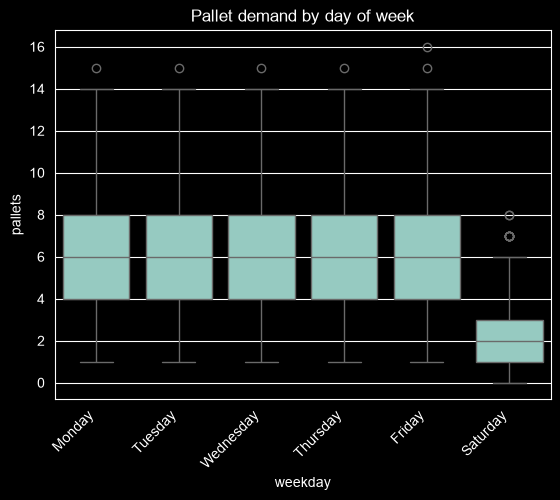

'\nThis pools all 55 stores together into one box per weekday. This is fine for a first look however the problem with this is that a high demand store can mask a low demand store.\n'

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

demand_df["weekday"] = demand_df["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    # "Sunday",
]

sns.boxplot(data=demand_df, x="weekday", y="pallets", order=weekday_order)
plt.title("Pallet demand by day of week")
plt.xticks(rotation=45, ha="right")
plt.show()

"""
This pools all 55 stores together into one box per weekday. This is fine for a first look however the problem with this is that a high demand store can mask a low demand store.
"""

In [4]:
demand_df = load_demand()
demand_df[demand_df["date"] == "2026-06-01"] # Kings Birthday, should return empty df

,store,date,pallets


In [5]:
demand_df = load_demand()
demand_df[(demand_df["store"] == "Pak 'n Save Albany") & (demand_df["date"] == "2026-06-03")] # Where demand exceeds capacity, should return empty df

,store,date,pallets


In [10]:
# noinspection PyInterpreter
from demand_averages import weekday_average, saturday_average
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

demand_df = load_demand()

weekday_avg = weekday_average(demand_df)
saturday_avg = saturday_average(demand_df)

display(weekday_avg)
display(saturday_avg)

,store,huber_mean_pallets,huber_pallets_ceil
0,Four Square Botany Junction,2.641026,3
1,Four Square Britomart,2.325481,3
2,Four Square Cockle Bay,2.256410,3
3,Four Square Eden Terrace,2.523810,3
4,Four Square Ellerslie,2.435897,3
5,Four Square Fair Price Henderson,2.461538,3
6,Four Square Glen Eden,2.589744,3
7,Four Square Hobsonville,2.641026,3
8,Four Square Lancaster,2.444626,3
9,Four Square Onehunga,2.266089,3


,store,huber_mean_pallets,huber_pallets_round
0,Four Square Botany Junction,3.750000e-01,0
1,Four Square Britomart,6.784797e-10,0
2,Four Square Cockle Bay,0.000000e+00,0
3,Four Square Eden Terrace,6.784797e-10,0
4,Four Square Ellerslie,3.750000e-01,0
5,Four Square Fair Price Henderson,3.750000e-01,0
6,Four Square Glen Eden,6.250000e-01,1
7,Four Square Hobsonville,6.250000e-01,1
8,Four Square Lancaster,6.250000e-01,1
9,Four Square Onehunga,3.750000e-01,0


In [1]:
from demand_averages import weekday_average, saturday_average
from load_data import load_durations, load_demand
import pandas as pd
import matplotlib.pyplot as plt

durations_df = load_durations()

demand_df = load_demand()

weekday_avg_df = weekday_average(demand_df)   # one huber_mean_pallets value per store
saturday_avg_df = saturday_average(demand_df)

def driving_budget_per_leg(avg_pallets_per_store, num_stores_on_route,
                            trip_cap_minutes=210, unload_min_per_pallet=18):
    """
    Given an assumed route size (num_stores_on_route) and average pallets
    per store, work out how much of the 3.5hr trip cap is left for driving
    after unloading, and split that evenly across the legs of the route
    (depot -> store1 -> ... -> storeN -> depot = N+1 legs).
    """
    total_unload_min = num_stores_on_route * avg_pallets_per_store * unload_min_per_pallet
    driving_budget_min = trip_cap_minutes - total_unload_min
    num_legs = num_stores_on_route + 1
    return driving_budget_min, driving_budget_min / num_legs


def budget_table(avg_pallets_per_store, label, n_range=range(1, 9)):
    """Build a tidy table of driving budget by route size for a given day-type."""
    rows = []
    for n in n_range:
        budget, per_leg = driving_budget_per_leg(avg_pallets_per_store, n)
        rows.append({"day_type": label, "num_stores": n,
                      "driving_budget_min": budget, "per_leg_min": per_leg})
    return pd.DataFrame(rows)

weekday_table = budget_table(weekday_avg_df["huber_mean_pallets"].mean(), "Weekday")
saturday_table = budget_table(saturday_avg_df["huber_mean_pallets"].mean(), "Saturday")

budget_df = pd.concat([weekday_table, saturday_table], ignore_index=True)
display(weekday_table)
saturday_table

/Users/avishainarsey/Documents/Projects/ML_Projects/ENGSCI-263-Team-01/.venv/lib/python3.14/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/Users/avishainarsey/Documents/Projects/ML_Projects/ENGSCI-263-Team-01/.venv/lib/python3.14/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/Users/avishainarsey/Documents/Projects/ML_Projects/ENGSCI-263-Team-01/.venv/lib/python3.14/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimate

,day_type,num_stores,driving_budget_min,per_leg_min
0,Weekday,1,100.199337,50.099669
1,Weekday,2,-9.601325,-3.200442
2,Weekday,3,-119.401988,-29.850497
3,Weekday,4,-229.202651,-45.840530
4,Weekday,5,-339.003313,-56.500552
5,Weekday,6,-448.803976,-64.114854
6,Weekday,7,-558.604638,-69.825580
7,Weekday,8,-668.405301,-74.267256


,day_type,num_stores,driving_budget_min,per_leg_min
0,Saturday,1,167.482796,83.741398
1,Saturday,2,124.965591,41.655197
2,Saturday,3,82.448387,20.612097
3,Saturday,4,39.931182,7.986236
4,Saturday,5,-2.586022,-0.431004
5,Saturday,6,-45.103226,-6.443318
6,Saturday,7,-87.620431,-10.952554
7,Saturday,8,-130.137635,-14.459737


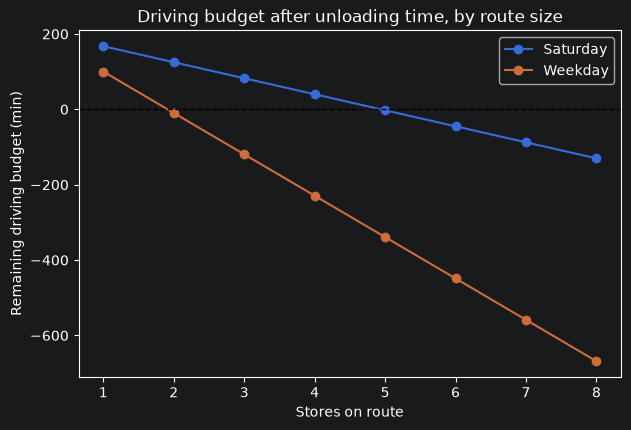

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for label, group in budget_df.groupby("day_type"):
    ax.plot(group["num_stores"], group["driving_budget_min"], marker="o", label=label)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Stores on route")
ax.set_ylabel("Remaining driving budget (min)")
ax.set_title("Driving budget after unloading time, by route size")
ax.legend()
plt.show()

**Finding:** at average weekday demand (~6.1 pallets/store), unloading time alone exceeds the 3.5hr no-overtime cap once a route has more than 1 store — meaning overtime is essentially unavoidable for realistic weekday routes, and truck capacity (16 pallets), not driving distance, is the binding constraint on route size. Saturday (~2.3 pallets/store) has more slack, staying within budget up to ~4 stores.